In [ ]:
# pip install jupyter_bokeh
#adapated from https://github.com/MannLabs/pydiaid/blob/main/nbs/diaPASEF_method%20_generation.ipynb

In [9]:
%reload_ext autoreload
%autoreload 2

import os
import pandas as pd

## Optimize a dia-PASEF method in Jupyter notebook

In [29]:
import pydiaid.diapasef.cli as cli #todo
import pandas as pd
import pydiaid.loader as loader
import pydiaid.diapasef.graphs as graphs
import pydiaid.diapasef.main as main
import pydiaid.diapasef.method_evaluation as evaluator


In [34]:
defaults = {   
    "method_parameters": {
        "mz": [300,1200],
        "ion_mobility": [0.6,1.6],
        "num_dia_pasef_scans": 20,
        "im_steps": 2,
        "overlap": 0,
        "shift_of_final_method": 0,
        "max_width": 100
    },
    "graphs": {
        "plot_mz": [250, 1250],
        "plot_IM": [0.6, 1.6],
        "numbins": 100,
        "window_frame_color": "black",
        "window_color": "white",
        "window_transparency": 0.5
    },
    "optimizer": {
        "optimizer": "Gauss",
        "n_calls": 100, #todo set to 100
        "initial_points": 20, #todo set to 20
        "YA1": [0.5, 0.9],
        "YA2": [0.6, 1.0],
        "YB1": [0.9, 1.5],
        "YB2": [1.0, 1.8],
        "evaluation_parameter": "No. of covered precursors"
    }
}

In [32]:
method_conf = {
    "input": {
        "save_at": "/Users/eileen.wang/Desktop/diann/SampleData/pydiad_outputs/test",
        "PTM": "None",
        "library_name": "/Users/eileen.wang/Desktop/diann/SampleData/FP/SpecLibs/HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_18p6m200nlv28_DDA70ms1500Vnopoly_TT0000258_B_A8_1_14659_speclib_autorefRT/library_nocharge1.tsv",
        "analysis_software": "MSFragger",
    },
    "method_parameters": {
        "mz": [300,1200],
        "ion_mobility": [0.6,1.6],
        "num_dia_pasef_scans": 20,
        "im_steps": 2,
        "overlap": 0,
        "shift_of_final_method": 0,
        "max_width": 100
    },
    "graphs": {
        "plot_mz": [250, 1250],
        "plot_IM": [0.6, 1.6],
        "numbins": 100,
        "window_frame_color": "black",
        "window_color": "white",
        "window_transparency": 0.5
    },
    "optimizer": {
        "optimizer": "Gauss",
        "n_calls": 100, #todo set to 100
        "initial_points": 20, #todo set to 20
        "YA1": [0.5, 0.9],
        "YA2": [0.6, 1.0],
        "YB1": [0.9, 1.5],
        "YB2": [1.0, 1.8],
        "evaluation_parameter": "No. of covered precursors"
    }
}

In [33]:
%%capture
cli.run_all(
    method_conf
)

# The output can be found in the folder specified at "save_at".

## Here, we present the method evaluation steps:

#### Loading of the dia-PASEF method and the library.

In [15]:
lib_name = method_conf["input"]["library_name"]
dia_PASEF = method_conf["input"]["save_at"]+"/final_method/diaPASEF_method.txt"

In [10]:
df_parameters_final = pd.read_csv(
        dia_PASEF,
        skiprows=4,
        names=["MS Type", "Cycle Id", "Start IM", "End IM", "Start Mass", "End Mass", "CE"]
        )

In [14]:
lib = loader.load_library(
    lib_name,
    'MSFragger',
    'None'
)
lib

,mz,Charge,Proteins,Peptide,IM
0,295.150871,3,P49748,AVDHATNR,0.685066
7,295.171383,3,P39748,RKEPEPK,0.671668
13,298.831249,3,A0A804HKE7,HKPGGGDVK,0.687641
20,303.466748,3,P38159,DYGHSSSR,0.689459
26,304.160712,3,Q8NFH4,RPVHMDR,0.674439
...,...,...,...,...,...
637519,1497.217858,2,Q9NR45,PLNPNFC(UniMod:4)FLQC(UniMod:4)TSAYPLQPEDVNLR,1.402263
637527,1497.764010,2,A6NLN1,NFQNIFPPSATLHLSNIPPSVSEEDLK,1.415283
637535,1498.203559,2,P68104,SGDAAIVDMVPGKPMC(UniMod:4)VESFSDYPPLGR,1.408632
637545,1498.726571,2,P62266,ITAFVPNDGC(UniMod:4)LNFIEENDEVLVAGFGR,1.416661


## Generate method

In [17]:
dia_PASEF 

'/Users/eileen.wang/Desktop/diann/SampleData/pydiad_outputs/test/final_method/diaPASEF_method.txt'

In [ ]:
df_parameters_final = main.create_final_method(
    lib,
    method_conf["method_parameters"],
    [0.4330575116541656, 1.0070492479199211, 1.4648806673371042, 1.450133190094871], # coordinates of scan area
    method_conf
)

df_parameters_final["End Mass"].max()

np.float64(1199.65)

#### Generating plots that belong only to the library.

In [19]:
x, y, z = graphs.kernel_density_calculation(
    lib,
    100,
)

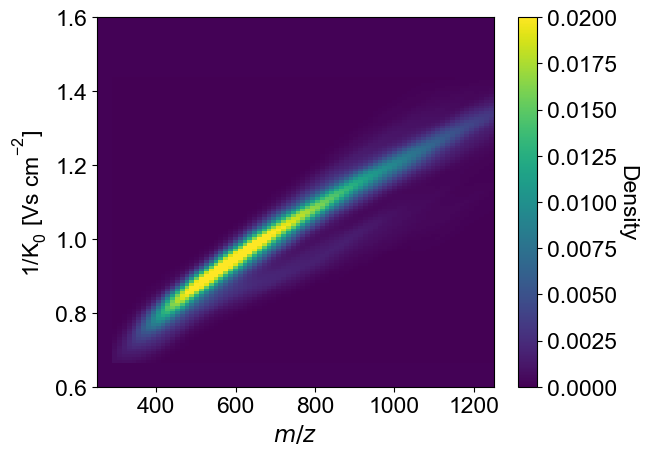

In [20]:
plt_proteomics = graphs.plot_density(
    x,
    y,
    z,
    method_conf["graphs"],
    method_conf["input"]["save_at"]+r"/Plot_proteomics_precursors.pdf",
    gui = True
)

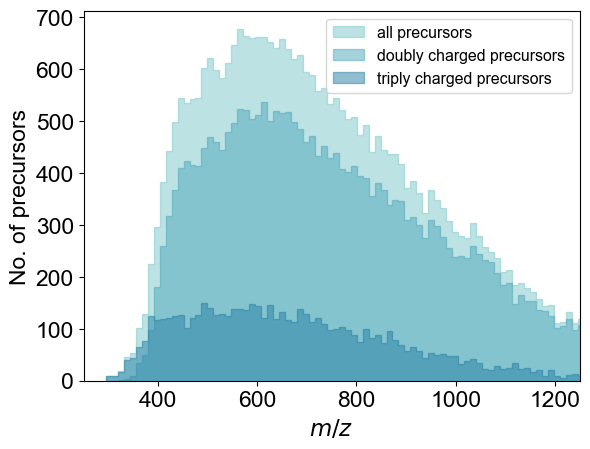

In [21]:
hist_mz = graphs.plot_precursor_distribution_as_histogram(
    lib,
    method_conf["graphs"],
    os.path.join(method_conf["input"]["save_at"], "Histogram_proteomics_precursors_mz.pdf"),
    gui = True    
)

#### Plotting the dia-PASEF method on top of the kernel density distribution.

In [22]:
import panel as pn
pn.extension()

In [23]:
save_figure_at = os.path.join(method_conf["input"]["save_at"], "Plot_method.png")

graphs.plot_density_and_method(
    df_parameters_final,
    x,
    y,
    z,
    method_conf["graphs"],
    save_figure_at,
)

<Figure size 640x480 with 0 Axes>

PNG(str, align='center', height=345, margin=(0, 20, 0, 0), sizing_mode='fixed', width=460)
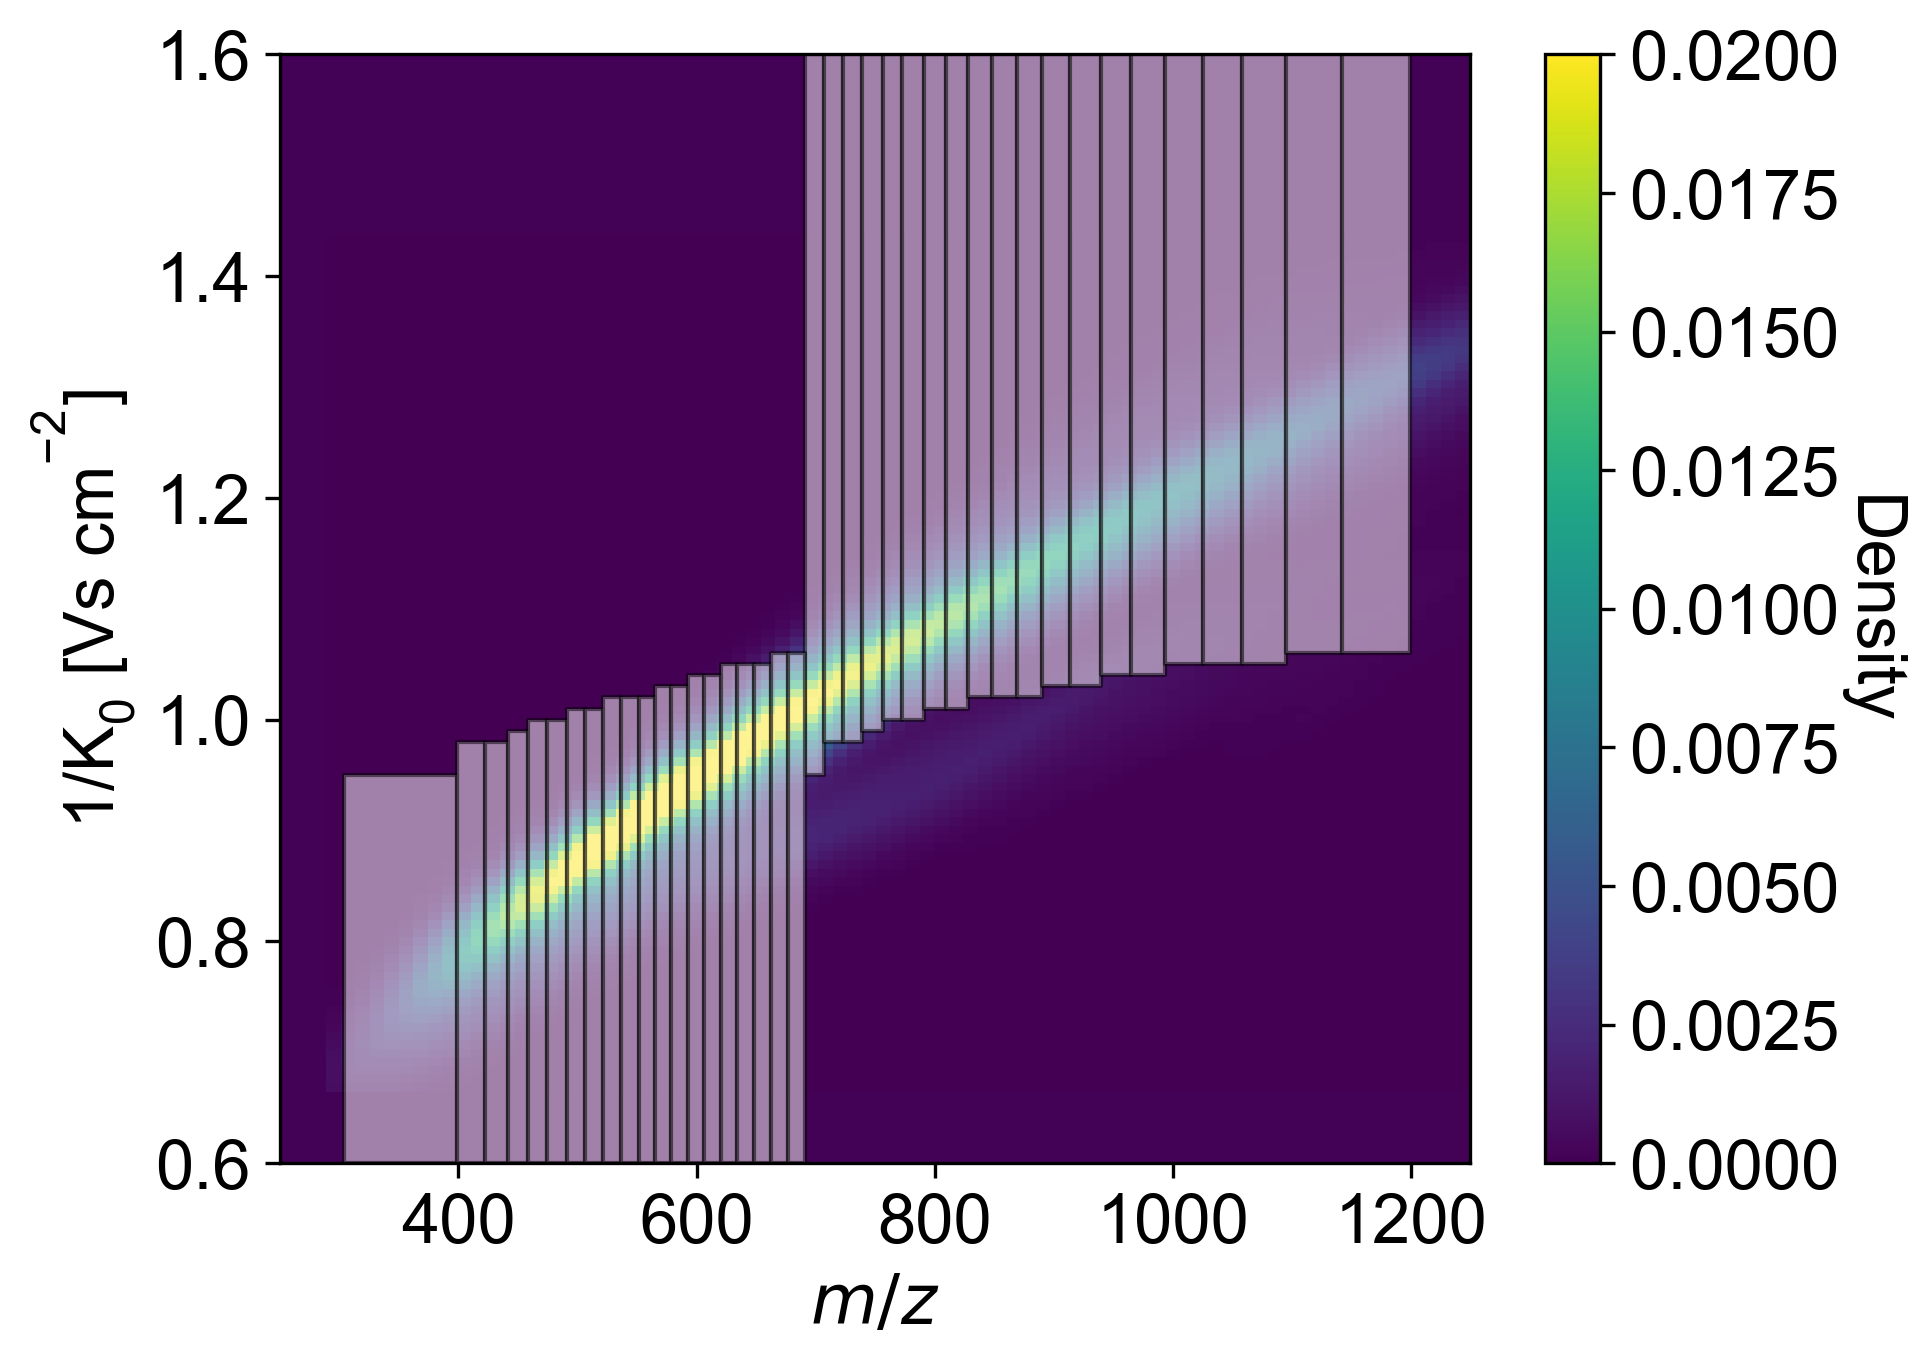

In [24]:
pn.pane.PNG(
    save_figure_at,
    height=345,
    width=460,
    align='center',
    margin=(0, 20, 0, 0)
)

#### Evaluate the die-PASEF method.

In [26]:
dict_coverage = evaluator.coverage(
    df_parameters_final,
    lib,
)
dict_coverage

division by zero singly charged precursours are not present


{'unique proteins in the library': 4380,
 'unique precursors in the library': 31727,
 'smallest diaPASEF window': np.float64(13.52),
 'biggest diaPASEF window': np.float64(95.25),
 'average diaPASEF window size': np.float64(22.4),
 'No. of covered proteins': 4298,
 'No. of covered precursors': 28994,
 'all proteins covered': '98.1%',
 'all precursors covered': '91.4%',
 'No. of covered, doubly charged precursors': 23795,
 'all doubly charged precursors covered': '94.5%',
 'No. of covered, triply charged precursors': 4918,
 'all triply charged precursors covered': '79.2%',
 'No. of covered, quadruply charged precursors': 275,
 'all quadruply charged precursors covered': '84.6%',
 'No. of covered, singly charged precursors': 0,
 'all singly charged precursors covered': 0}

## make gif

In [27]:
import imageio.v3 as iio

In [ ]:
# Read the method file
df_parameters_final = pd.read_csv(
    "/Users/patriciaskowronek/Documents/pydiaid/pydiaid/diapasef/static/diaPASEF_method.txt",
    skiprows=4,
    names=["MS Type", "Cycle Id", "Start IM", "End IM", "Start Mass", "End Mass", "CE"]
)

# Generate boxes with 10 steps per window
boxes, df_filtered = graphs.generate_dia_boxes(df_parameters_final, im_steps=10)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
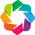

<Figure size 640x480 with 0 Axes>

In [21]:
import pydiaid.synchropasef.method_creator as syP_method_creator
import pydiaid.synchropasef.plots as syP_plots

# Location where the individual plots and the complete gif will be saved
save_at = '/Users/patriciaskowronek/Documents/test_folder/gif/'
syP_method_creator.create_folder([save_at])

syP_plots.generate_gif_single_windows(
    x,
    y,
    z,
    method_conf["graphs"],
    boxes,
    range(1, len(df_filtered)+1),
    save_at,
    # facecolor="#FF0098",
    window_color = "white_grey",
    scans_plotted_at_once=1,
)

In [22]:
png_dir = save_at[:-1]
print(save_at[:-1])
images = []
for file_name in sorted(os.listdir(png_dir)):
    if file_name.endswith('.png'):
        file_path = os.path.join(png_dir, file_name)
        images.append(iio.imread(file_path))
iio.imwrite(save_at + 'diaPASEF.gif', images, duration = 0.001, loop = 0)

/Users/patriciaskowronek/Documents/test_folder/gif
